# Requirement 3 - improved version

Same instance and the same two environments as the baseline version. The primal-dual structure remains identical; two points change:

1. learning rates come from Hedge and OGD theory rather than the cautious constants of the baseline: eta_Hedge = sqrt(8 log K / T) on normalized gains in [0,1], eta_OGD = lambda_max / (G sqrt(T)) with G a bound on the dual gradient;
2. budget control is per action: only the sampled action that cannot be paid is replaced with the null super-action, rather than stopping everything when the remaining budget does not cover the worst-case round.

The ablation at the end isolates the effect of the budget rule from the learning rates.

In [10]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, stats

SEED = 17
T = 3000
TRIALS = 10
B = 700.0
RHO = B / T

# same instance as Requirement 2
BID_GRID = np.linspace(0.0, 1.0, 11)
VALUES = np.array([0.95, 0.85, 0.78, 0.90])
CONFLICT_EDGES = [(0, 1), (1, 2), (2, 3)]
N_CAMPAIGNS = len(VALUES)

# Requirement 2 stochastic environment: Beta marginals per campaign with a common factor
BETA_PARAMS = [(2.0, 5.0), (2.8, 3.8), (3.5, 3.0), (2.3, 4.0)]
CORR_P = 0.3

np.set_printoptions(precision=3, suppress=True)

## Super-actions

In [11]:
grids = [BID_GRID[BID_GRID <= VALUES[i]] for i in range(N_CAMPAIGNS)]

superactions = []
for bids in itertools.product(*grids):
    bids = np.array(bids)
    if any(bids[i] > 0 and bids[j] > 0 for i, j in CONFLICT_EDGES):
        continue
    superactions.append(bids)

SA_BIDS = np.array(superactions)          # (K, N_CAMPAIGNS)
SA_BID_SUMS = SA_BIDS.sum(axis=1)
K = len(SA_BIDS)
NULL_IDX = 0
assert np.all(SA_BIDS[NULL_IDX] == 0)

MAX_ROUND_REWARD = float(VALUES.sum())
MAX_ROUND_COST = float(SA_BID_SUMS.max())

print(f'K = {K} super-actions, maximum cost per round = {MAX_ROUND_COST:.2f}')

K = 250 super-actions, maximum cost per round = 1.80


## Environments

Identical to the baseline version: only the algorithm differs between the two notebooks.

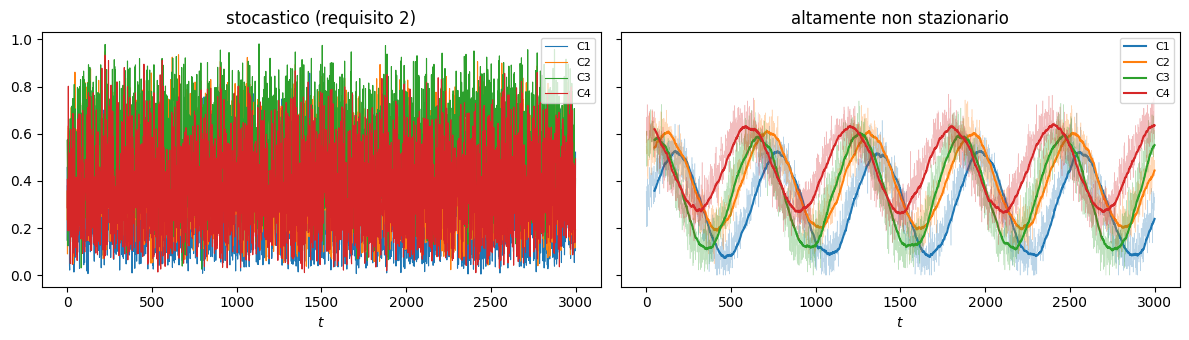

In [12]:
def build_stochastic_sequence(horizon, seed):
    # Requirement 2 stochastic environment: Beta marginals with a common factor
    # (in a fraction CORR_P of rounds all campaigns share the same quantile)
    rng = np.random.default_rng(seed)
    u = rng.uniform(size=(horizon, N_CAMPAIGNS))
    common = rng.uniform(size=horizon)
    shared = rng.uniform(size=horizon) < CORR_P
    u[shared] = common[shared, None]
    M = np.zeros((horizon, N_CAMPAIGNS))
    for i, (a, b) in enumerate(BETA_PARAMS):
        M[:, i] = stats.beta.ppf(u[:, i], a, b)
    return M


def build_nonstationary_sequence(horizon, seed):
    # non-stochastic sequence: each threshold follows a fast sinusoid with its own phase,
    # so attractive campaigns rotate over time; small noise avoids exact periodicity
    t = np.arange(horizon) / horizon
    base = np.array([0.30, 0.40, 0.35, 0.45])
    amp = np.array([0.22, 0.20, 0.24, 0.18])
    phase = np.array([0.0, 0.6, 1.2, 1.8])
    M = base + amp * np.sin(2 * np.pi * 5 * t[:, None] + phase)
    M = M + np.random.default_rng(seed).normal(0, 0.05, M.shape)
    return np.clip(M, 0.0, 1.0)


def build_sequence(regime, horizon, seed):
    if regime == 'stochastic':
        return build_stochastic_sequence(horizon, seed)
    return build_nonstationary_sequence(horizon, seed)


def feedback_matrices(M):
    # full feedback: counterfactual reward and cost of every super-action, matrices (T, K)
    wins = SA_BIDS[None, :, :] >= M[:, None, :]
    F = ((VALUES - SA_BIDS)[None, :, :] * wins).sum(axis=2)
    C = (SA_BIDS[None, :, :] * wins).sum(axis=2)
    return F, C


w = 50   # moving-average window, to reveal the structure beneath noise
Mst = build_sequence('stochastic', T, SEED)
Mns = build_sequence('nonstationary', T, SEED)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for i in range(N_CAMPAIGNS):
    axes[0].plot(Mst[:, i], lw=0.8, label=f'C{i+1}')
    axes[1].plot(Mns[:, i], lw=0.4, alpha=0.3, color=f'C{i}')
    roll = np.convolve(Mns[:, i], np.ones(w) / w, mode='valid')
    axes[1].plot(np.arange(w - 1, T), roll, lw=1.5, color=f'C{i}', label=f'C{i+1}')
axes[0].set_title('stocastico (requisito 2)')
axes[1].set_title('highly non-stationary')
for ax in axes:
    ax.set_xlabel('$t$')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## Clairvoyant

In [13]:
def compute_clairvoyant(f_avg, c_avg, rho):
    res = optimize.linprog(-f_avg, A_ub=[c_avg], b_ub=[rho],
                           A_eq=[np.ones(K)], b_eq=[1], bounds=(0, 1), method='highs')
    x = np.maximum(res.x, 0)
    x = x / x.sum()
    return x, f_avg @ x, c_avg @ x

## Agent

Hedge receives the action-dependent part of the Lagrangian, g_t(a) = f_t(a) - lambda_t c_t(a): the term lambda_t rho is constant and does not change the distribution. Normalization uses fixed bounds as in the baseline version.

Note: when the budget replacement is triggered, Hedge and the dual variable are still updated on the proposed distribution x_t, while the budget decreases by the cost of the executed action. This is the same asymmetry as in the baseline version (expected cost in the dual update, realized cost in the budget); the results table reports how often replacement occurs.

In [14]:
class HedgeAgent:
    def __init__(self, K, learning_rate):
        self.K = K
        self.learning_rate = learning_rate
        self.weights = np.ones(K)
        self.x_t = np.ones(K) / K

    def choose_distribution(self):
        self.x_t = self.weights / self.weights.sum()
        return self.x_t

    def update(self, l_t):
        self.weights *= np.exp(-self.learning_rate * l_t)
        self.weights /= self.weights.max()   # riscala i pesi, x_t non cambia

In [15]:
class ImprovedPrimalDualAgent:
    def __init__(self, K, B, T, seed, budget_check='per_action'):
        self.hedge = HedgeAgent(K, np.sqrt(8 * np.log(K) / T))
        self.budget = B
        self.rho = B / T
        self.lmbd_max = 1 / self.rho
        G = max(self.rho, MAX_ROUND_COST - self.rho)     # bound sul gradiente duale
        self.eta = self.lmbd_max / (G * np.sqrt(T))
        self.lmbd = 1.0
        self.rng = np.random.default_rng(seed)
        self.budget_check = budget_check
        # fixed bounds to normalize g = f - lambda*c in [0,1]
        self.g_low = -self.lmbd_max * MAX_ROUND_COST
        self.g_range = MAX_ROUND_REWARD - self.g_low
        self.x_t = np.ones(K) / K
        self.a_t = NULL_IDX
        self.n_overrides = 0

    def pull_arm(self):
        if self.budget_check == 'global_stop' and self.budget < MAX_ROUND_COST:
            self.x_t = np.zeros(K)
            self.x_t[NULL_IDX] = 1.0
            self.a_t = NULL_IDX
            return self.a_t
        self.x_t = self.hedge.choose_distribution()
        self.a_t = self.rng.choice(K, p=self.x_t)
        # replace the sampled action only if its maximum payment exceeds the budget
        if SA_BID_SUMS[self.a_t] > self.budget:
            self.a_t = NULL_IDX
            self.n_overrides += 1
        return self.a_t

    def update(self, f_t, c_t):
        # lambda*rho is constant across actions and does not change Hedge’s distribution
        g = f_t - self.lmbd * c_t
        self.hedge.update(1 - (g - self.g_low) / self.g_range)   # Hedge massimizza g
        expected_cost = c_t @ self.x_t
        self.lmbd = np.clip(self.lmbd - self.eta * (self.rho - expected_cost),
                            0, self.lmbd_max)
        self.budget -= c_t[self.a_t]


class RandomAgent:
    def __init__(self, K, B, seed):
        self.budget = B
        self.rng = np.random.default_rng(seed)
        self.x_t = np.ones(K) / K
        self.a_t = NULL_IDX
        self.lmbd = np.nan
        self.n_overrides = 0

    def pull_arm(self):
        feasible = SA_BID_SUMS <= self.budget
        feasible[NULL_IDX] = True
        self.x_t = feasible / feasible.sum()
        self.a_t = self.rng.choice(K, p=self.x_t)
        return self.a_t

    def update(self, f_t, c_t):
        self.budget -= c_t[self.a_t]

## Simulation

In [16]:
def run_trial(regime, agent_kind, horizon, budget, seed, budget_check="per_action"):
    M = build_sequence(regime, horizon, seed)
    F, C = feedback_matrices(M)
    rho = budget / horizon
    clairvoyant_x, _, _ = compute_clairvoyant(F.mean(axis=0), C.mean(axis=0), rho)
    clairvoyant_rewards = F @ clairvoyant_x

    if agent_kind == 'primal_dual':
        agent = ImprovedPrimalDualAgent(K, budget, horizon, seed + 10_000, budget_check)
    else:
        agent = RandomAgent(K, budget, seed + 20_000)

    exp_rewards = np.zeros(horizon)
    actual_rewards = np.zeros(horizon)
    actual_costs = np.zeros(horizon)
    lmbds = np.zeros(horizon)

    for t in range(horizon):
        a_t = agent.pull_arm()
        f_t, c_t = F[t], C[t]
        exp_rewards[t] = f_t @ agent.x_t
        actual_rewards[t] = f_t[a_t]
        actual_costs[t] = c_t[a_t]
        lmbds[t] = agent.lmbd
        agent.update(f_t, c_t)

    return {
        'pseudo_regret': clairvoyant_rewards - exp_rewards,
        'actual_reward': actual_rewards,
        'actual_cost': actual_costs,
        'lambda': lmbds,
        'override_rate': agent.n_overrides / horizon,
        'clairvoyant_reward': clairvoyant_rewards,
    }


results = {}
for regime in ['stochastic', 'nonstationary']:
    results[regime] = {}
    for agent_kind in ['primal_dual', 'random']:
        runs = []
        for trial in range(TRIALS):
            seed = SEED + 1000 * trial + (100_000 if regime == 'nonstationary' else 0)
            runs.append(run_trial(regime, agent_kind, T, B, seed))
        results[regime][agent_kind] = runs

print('fatto')

fatto


## Results

In [17]:
print(f'{"regime":<15}{"agent":<13}{"reward":>9}{"regret/T":>10}{"expenditure":>9}{"override":>10}{"violation":>12}')
for regime in results:
    for agent_kind, runs in results[regime].items():
        reward = np.mean([r['actual_reward'].sum() for r in runs])
        regret = np.mean([r['pseudo_regret'].sum() for r in runs]) / T
        spend = np.mean([r['actual_cost'].sum() for r in runs])
        overrides = np.mean([r['override_rate'] for r in runs])
        violation = max(0.0, max(r['actual_cost'].sum() for r in runs) - B)
        print(f'{regime:<15}{agent_kind:<13}{reward:>9.1f}{regret:>10.3f}{spend:>9.1f}{overrides:>10.3f}{violation:>12.2f}')

regime         agent          reward  regret/T    expenditure  override  violation
stochastic     primal_dual     1287.9     0.121    675.8     0.000        0.00
stochastic     random           342.1     0.436    700.0     0.000        0.00
nonstationary  primal_dual     1100.0     0.134    596.8     0.000        0.00
nonstationary  random           334.1     0.391    699.9     0.000        0.00


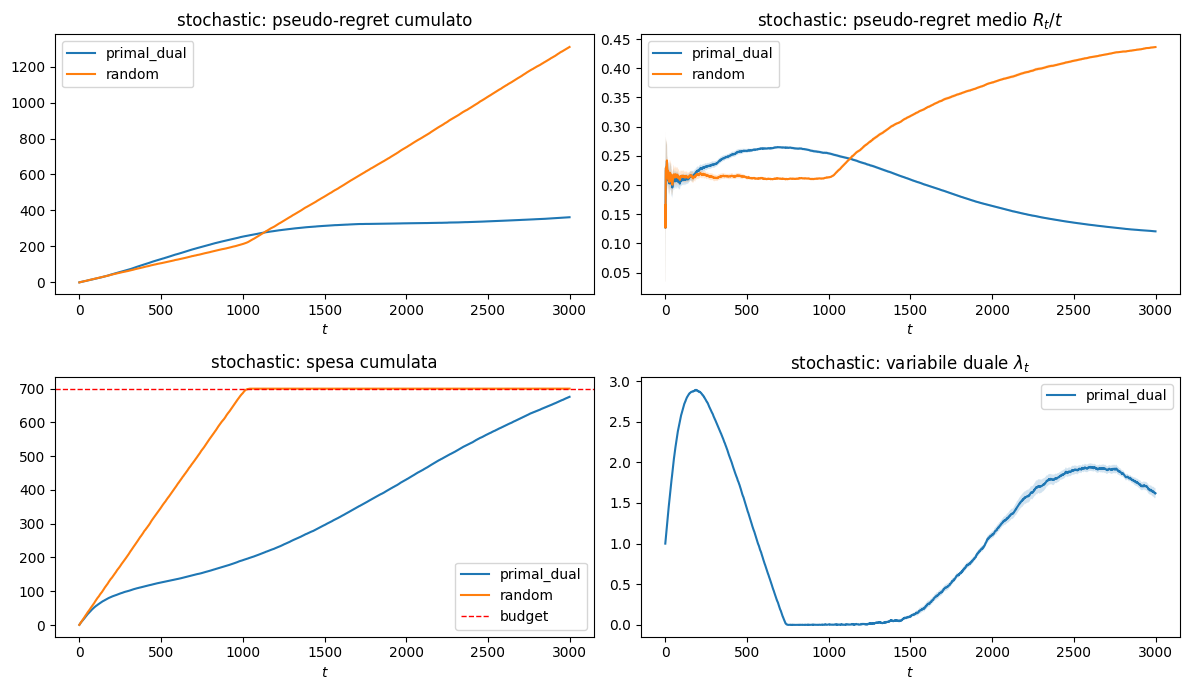

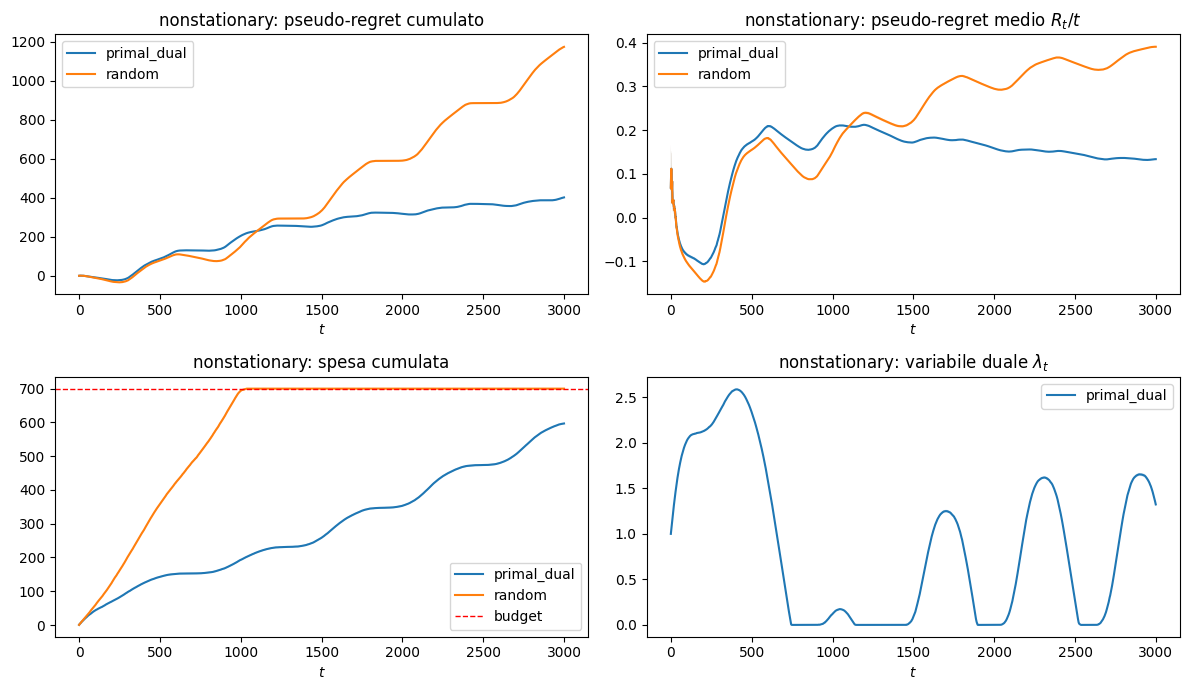

In [18]:
def plot_mean_sem(ax, data, label):
    data = np.array(data)
    mean = data.mean(axis=0)
    sem = data.std(axis=0, ddof=1) / np.sqrt(len(data))
    ax.plot(mean, label=label)
    ax.fill_between(np.arange(len(mean)), mean - sem, mean + sem, alpha=0.2)


for regime in ['stochastic', 'nonstationary']:
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    axes = axes.ravel()
    for agent_kind in ['primal_dual', 'random']:
        runs = results[regime][agent_kind]
        plot_mean_sem(axes[0], [np.cumsum(r['pseudo_regret']) for r in runs], agent_kind)
        plot_mean_sem(axes[1], [np.cumsum(r['pseudo_regret']) / np.arange(1, T + 1) for r in runs], agent_kind)
        plot_mean_sem(axes[2], [np.cumsum(r['actual_cost']) for r in runs], agent_kind)
    runs = results[regime]['primal_dual']
    plot_mean_sem(axes[3], [r['lambda'] for r in runs], 'primal_dual')
    axes[2].axhline(B, color='red', ls='--', lw=1, label='budget')
    axes[0].set_title(f'{regime}: pseudo-regret cumulato')
    axes[1].set_title(f'{regime}: pseudo-regret medio $R_t/t$')
    axes[2].set_title(f'{regime}: cumulative expenditure')
    axes[3].set_title(f'{regime}: variabile duale $\\lambda_t$')
    for ax in axes:
        ax.set_xlabel('$t$')
        ax.legend()
    plt.tight_layout()
    plt.show()

## Comparison with the baseline version, same environments

The baseline agent is re-run here with the same seeds: the difference between the curves only depends on the algorithmic changes.

In [19]:
class LabPacingAgent:
    # same baseline agent, re-run here on the same seeds
    def __init__(self, K, B, T, seed):
        self.hedge = HedgeAgent(K, np.sqrt(np.log(K) / T))
        self.budget = B
        self.rho = B / T
        self.eta = 1 / np.sqrt(T)
        self.lmbd = 1.0
        self.rng = np.random.default_rng(seed)
        self.L_up = MAX_ROUND_REWARD + (1 / self.rho) * self.rho
        self.L_low = -(1 / self.rho) * (MAX_ROUND_COST - self.rho)
        self.x_t = np.ones(K) / K
        self.a_t = NULL_IDX

    def pull_arm(self):
        if self.budget < MAX_ROUND_COST:
            self.x_t = np.zeros(K)
            self.x_t[NULL_IDX] = 1.0
            self.a_t = NULL_IDX
            return self.a_t
        self.x_t = self.hedge.choose_distribution()
        self.a_t = self.rng.choice(K, p=self.x_t)
        return self.a_t

    def update(self, f_t, c_t):
        L = f_t - self.lmbd * (c_t - self.rho)
        rescaled_L = (L - self.L_low) / (self.L_up - self.L_low)
        self.hedge.update(1 - rescaled_L)
        expected_cost = c_t @ self.x_t
        self.lmbd = np.clip(self.lmbd - self.eta * (self.rho - expected_cost),
                            0, 1 / self.rho)
        self.budget -= c_t[self.a_t]


def run_lab_agent(regime, horizon, budget, seed):
    M = build_sequence(regime, horizon, seed)
    F, C = feedback_matrices(M)
    clairvoyant_x, _, _ = compute_clairvoyant(F.mean(axis=0), C.mean(axis=0), budget / horizon)
    clairvoyant_rewards = F @ clairvoyant_x
    agent = LabPacingAgent(K, budget, horizon, seed + 10_000)
    exp_rewards = np.zeros(horizon)
    actual_rewards = np.zeros(horizon)
    actual_costs = np.zeros(horizon)
    for t in range(horizon):
        a_t = agent.pull_arm()
        exp_rewards[t] = F[t] @ agent.x_t
        actual_rewards[t] = F[t, a_t]
        actual_costs[t] = C[t, a_t]
        agent.update(F[t], C[t])
    return {'pseudo_regret': clairvoyant_rewards - exp_rewards,
            'actual_reward': actual_rewards, 'actual_cost': actual_costs}


print(f'{"regime":<15}{"agent":<13}{"reward":>9}{"regret/T":>10}{"expenditure":>9}')
for regime in ['stochastic', 'nonstationary']:
    lab_runs = []
    for trial in range(TRIALS):
        seed = SEED + 1000 * trial + (100_000 if regime == 'nonstationary' else 0)
        lab_runs.append(run_lab_agent(regime, T, B, seed))
    for label, runs in [('migliorato', results[regime]['primal_dual']), ('base', lab_runs)]:
        reward = np.mean([r['actual_reward'].sum() for r in runs])
        regret = np.mean([r['pseudo_regret'].sum() for r in runs]) / T
        spend = np.mean([r['actual_cost'].sum() for r in runs])
        print(f'{regime:<15}{label:<13}{reward:>9.1f}{regret:>10.3f}{spend:>9.1f}')

regime         agent          reward  regret/T    expenditure
stochastic     migliorato      1287.9     0.121    675.8
stochastic     base             895.8     0.249    568.6
nonstationary  migliorato      1100.0     0.134    596.8
nonstationary  base             835.4     0.222    557.6


## Ablation: per-action control vs global stop

Same learning rates, dual variable, and seeds; only the budget rule changes.

In [20]:
ablation_trials = 8
print(f'{"regime":<15}{"budget rule":<14}{"reward":>9}{"regret/T":>10}{"expenditure":>9}')
for regime in ['stochastic', 'nonstationary']:
    for budget_check in ['per_action', 'global_stop']:
        runs = []
        for trial in range(ablation_trials):
            seed = SEED + 1000 * trial + (100_000 if regime == 'nonstationary' else 0)
            runs.append(run_trial(regime, 'primal_dual', T, B, seed, budget_check))
        reward = np.mean([r['actual_reward'].sum() for r in runs])
        regret = np.mean([r['pseudo_regret'].sum() for r in runs]) / T
        spend = np.mean([r['actual_cost'].sum() for r in runs])
        print(f'{regime:<15}{budget_check:<14}{reward:>9.1f}{regret:>10.3f}{spend:>9.1f}')

regime         budget rule    reward  regret/T    expenditure
stochastic     per_action       1286.3     0.121    674.5
stochastic     global_stop      1286.3     0.121    674.5
nonstationary  per_action       1100.3     0.134    597.2
nonstationary  global_stop      1100.3     0.134    597.2


## Regret as T varies

Different horizons with the same rho, to check that mean regret per round decreases.

--- stochastic: pseudo-regret / T ---
T=100    primal_dual=0.2650   random=0.4327
T=200    primal_dual=0.2638   random=0.4310
T=300    primal_dual=0.2609   random=0.4399
T=500    primal_dual=0.2380   random=0.4375
T=800    primal_dual=0.2042   random=0.4341
T=1200   primal_dual=0.1745   random=0.4344
T=1600   primal_dual=0.1528   random=0.4345
T=2400   primal_dual=0.1299   random=0.4357
T=3000   primal_dual=0.1209   random=0.4354
--- nonstationary: pseudo-regret / T ---
T=100    primal_dual=0.2335   random=0.3801
T=200    primal_dual=0.2357   random=0.3895
T=300    primal_dual=0.2315   random=0.3917
T=500    primal_dual=0.2111   random=0.3883
T=800    primal_dual=0.1919   random=0.3903
T=1200   primal_dual=0.1712   random=0.3908
T=1600   primal_dual=0.1547   random=0.3908
T=2400   primal_dual=0.1389   random=0.3902
T=3000   primal_dual=0.1337   random=0.3902


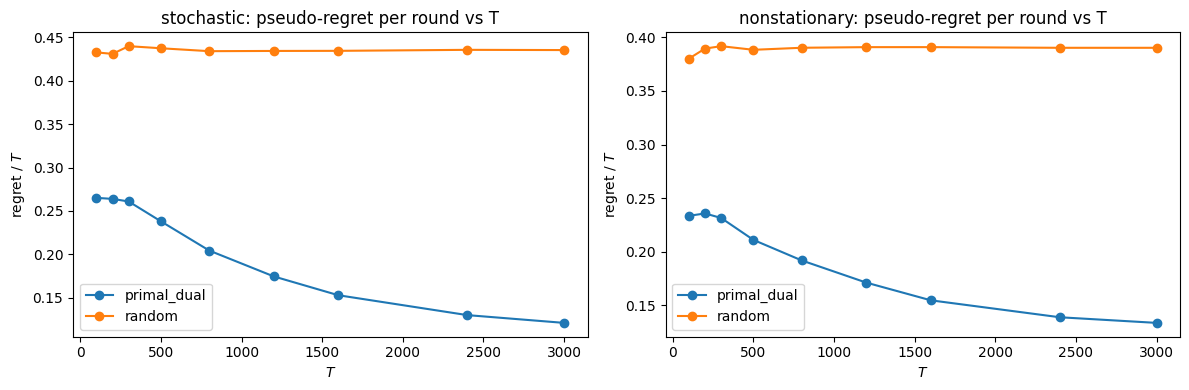

In [21]:
horizons = [100, 200, 300, 500, 800, 1200, 1600, 2400, 3000]
sweep = {regime: {kind: [] for kind in ['primal_dual', 'random']}
         for regime in ['stochastic', 'nonstationary']}

for horizon in horizons:
    for regime in sweep:
        for agent_kind in sweep[regime]:
            regrets = []
            for trial in range(8):
                seed = SEED + 1000 * trial + (100_000 if regime == 'nonstationary' else 0)
                run = run_trial(regime, agent_kind, horizon, RHO * horizon, seed)
                regrets.append(run['pseudo_regret'].sum())
            sweep[regime][agent_kind].append(np.mean(regrets) / horizon)

for regime in sweep:
    print(f'--- {regime}: pseudo-regret / T ---')
    for h, pd_v, rd_v in zip(horizons, sweep[regime]['primal_dual'], sweep[regime]['random']):
        print(f'T={h:<6} primal_dual={pd_v:.4f}   random={rd_v:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, regime in zip(axes, sweep):
    for agent_kind in sweep[regime]:
        ax.plot(horizons, sweep[regime][agent_kind], marker='o', label=agent_kind)
    ax.set_title(f'{regime}: pseudo-regret per round vs T')
    ax.set_xlabel('$T$')
    ax.set_ylabel('regret / $T$')
    ax.legend()
plt.tight_layout()
plt.show()

## Comments

- With the same environments and seeds, regret/T falls from 0.249 to 0.121 in the stochastic case and from 0.222 to 0.134 in the non-stationary one; expenditure rises to about 676 and 597 out of 700, always without violations.
- The ablation shows that the per-action rule and global stop give identical values on this instance: the gain comes entirely from the theoretical learning rates. The per-action rule remains because it controls the sampled action rather than the worst case, but it is not the source of the improvement (overrides are practically absent).
- The horizon sweep shows decreasing regret/T in both regimes (from about 0.27 to about 0.12 in the stochastic case, and from about 0.23 to about 0.13 in the non-stationary one): this behavior is compatible with sublinear regret.
- In the non-stationary regime, the comparator remains the best fixed distribution in hindsight (as in adversarial theory): the plots do not measure dynamic regret.